This project applies statistical methods to retail data to generate predictive insights that support better decision-making. The focus is not just on analyzing data, but on turning results into clear and actionable recommendations.

The approach goes beyond code execution—prioritizing efficiency, relevance, and practical impact. Each step is designed to highlight how data can be used to guide decisions, not just describe outcomes.

By combining structured analysis with assisted tools, the workflow emphasizes both speed and accuracy while maintaining thoughtful interpretation of results.


In [ ]:
import pandas as pd

In [ ]:
import kagglehub
anirudhchauhan_retail_store_inventory_forecasting_dataset_path = kagglehub.dataset_download('anirudhchauhan/retail-store-inventory-forecasting-dataset')

print('Data source import complete.')

100%|██████████| 1.51M/1.51M [00:00<00:00, 90.2MB/s]

Extracting files...
Data source import complete.


In [ ]:
print(anirudhchauhan_retail_store_inventory_forecasting_dataset_path)

/root/.cache/kagglehub/datasets/anirudhchauhan/retail-store-inventory-forecasting-dataset/versions/1


In [ ]:
import os

path = anirudhchauhan_retail_store_inventory_forecasting_dataset_path
print(os.listdir(path))

['retail_store_inventory.csv']


In [ ]:
import pandas as pd

file_path = path + '/retail_store_inventory.csv'
retail = pd.read_csv(file_path)

retail.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


Lets explore first the data

In [ ]:
retail['Price'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 73100 entries, 0 to 73099
Series name: Price
Non-Null Count  Dtype  
--------------  -----  
73100 non-null  float64
dtypes: float64(1)
memory usage: 571.2 KB


In [ ]:
retail['Holiday/Promotion'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 73100 entries, 0 to 73099
Series name: Holiday/Promotion
Non-Null Count  Dtype
--------------  -----
73100 non-null  int64
dtypes: int64(1)
memory usage: 571.2 KB


In [ ]:
retail['Holiday/Promotion']

,Holiday/Promotion
0,0
1,0
2,1
3,1
4,0
...,...
73095,0
73096,0
73097,0
73098,0


lets check the dates over season, it seems off. For example, autumn falls in the monh of September until November for north and you could see that in falls at January 1st 2022.

Either the date has another meaning which I hope the owner of the dataset attached.

This discrepancy has an immpact since it affectts the reliability of the data = lesser valif=dity of the outputs.

Lets assume the promotion 0 and 1 stands for 1 as yes and 0 as no as that is binary code. I hope this was added at kaggle.

In [ ]:
retail['Date']

,Date
0,2022-01-01
1,2022-01-01
2,2022-01-01
3,2022-01-01
4,2022-01-01
...,...
73095,2024-01-01
73096,2024-01-01
73097,2024-01-01
73098,2024-01-01


We wont removing the decimmals in the prices as we treat decimal as crucial info as they describe prices

Lets create better dictionary for yes and no

In [ ]:
retail['Holiday/Promotion'] = retail['Holiday/Promotion'].map({1: 'Yes', 0: 'No'})

In [ ]:
retail.head(5)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,No,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,No,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,Yes,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,Yes,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,No,68.95,Summer


Descriptive Analysis

In [ ]:
retail['Store ID'].nunique()

5

We are looking at the 5 stores across the north, south, east and west

In [ ]:
average_producsale = (
    retail.groupby(['Category', 'Weather Condition'])
          .agg(
        count_sale = ('Product ID', 'count')
    )
    .reset_index()
    .sort_values('count_sale', ascending=False)
)
print(average_producsale.head(5))

     Category Weather Condition  count_sale
9   Furniture             Rainy        3751
18       Toys             Snowy        3743
14  Groceries             Snowy        3705
3    Clothing             Sunny        3703
16       Toys            Cloudy        3700


In [ ]:
lowaverage_producsale = (
    retail.groupby(['Category', 'Weather Condition'])
          .agg(
        count_sale = ('Product ID', 'count')
    )
    .reset_index()
    .sort_values('count_sale', ascending=True)
)
print(lowaverage_producsale.head(5))

       Category Weather Condition  count_sale
17         Toys             Rainy        3578
12    Groceries            Cloudy        3581
5   Electronics             Rainy        3588
10    Furniture             Snowy        3600
2      Clothing             Snowy        3607


Furniture during rainy season is the peak sales while toys on the same weather is the low sales

In [ ]:
discount_byseason = (
    retail.groupby(['Category', 'Seasonality'])
          .agg(
              dis = ('Discount', 'mean')
    )
          .round(2)
          .reset_index()
          .sort_values('dis', ascending=False)
)
print(discount_byseason.head(5))

       Category Seasonality    dis
8     Furniture      Autumn  10.25
4   Electronics      Autumn  10.15
18         Toys      Summer  10.12
13    Groceries      Spring  10.08
5   Electronics      Spring  10.07


In [ ]:
lowdiscount_byseason = (
    retail.groupby(['Category', 'Seasonality'])
          .agg(
              dis = ('Discount', 'mean')
    )
          .round(2)
          .reset_index()
          .sort_values('dis', ascending=True)
)
print(lowdiscount_byseason.head(5))

     Category Seasonality   dis
16       Toys      Autumn  9.85
15  Groceries      Winter  9.87
10  Furniture      Summer  9.88
2    Clothing      Summer  9.95
14  Groceries      Summer  9.95


Note:


I was reading more about the demand forecast and found out that weather as tthe causality of price hikes is not a good relationship. This will show that they may have correlation BUT NOT SURE THE DIREECT CAUSALITY. As the saying goes,"Correlation DOES NOT MEAN CAUSATION" But lets find out through the graph to see the suggestted evidence by graph.

In [ ]:
retail.head(5)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,No,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,No,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,Yes,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,Yes,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,No,68.95,Summer


PROMMOTION/HOLIDAY

In [ ]:
promo = (
    retail.groupby(['Holiday/Promotion', 'Category','Region'])
    .agg(
        count_promo = ('Holiday/Promotion', 'count')
    )
    .reset_index()
    .sort_values('count_promo', ascending=False)
    [['Category','Region','count_promo']]
)
print(promo.head(5))


     Category Region  count_promo
9   Furniture  North         1908
20   Clothing   East         1897
17       Toys  North         1894
3    Clothing   West         1890
18       Toys  South         1882


This is better with year, maybe visuals will be better

Lets create a separate column for date? month only

In [ ]:
retail['Date'].value_counts()

,count
Date,
2024-01-01,100
2022-01-01,100
2022-01-02,100
2022-01-03,100
2022-01-04,100
...,...
2022-01-16,100
2022-01-15,100
2022-01-14,100


seems off as you could see all of the have the same month which is January maybe because its the time of reporting sales, so I think we will use the year instead

In [ ]:
# Safer version with error handling
retail['Date'] = pd.to_datetime(retail['Date'], errors='coerce')   # Convert to datetime
retail['Year'] = retail['Date'].dt.year
retail['Month'] = retail['Date'].dt.month

print("Year extraction done!")
print(retail[['Date', 'Year', 'Month']].head())

Year extraction done!
        Date  Year  Month
0 2022-01-01  2022      1
1 2022-01-01  2022      1
2 2022-01-01  2022      1
3 2022-01-01  2022      1
4 2022-01-01  2022      1


In [ ]:
retail.head(3)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Year,Month
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,No,29.69,Autumn,2022,1
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,No,66.16,Autumn,2022,1
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,Yes,31.32,Summer,2022,1


In [ ]:
retail['Month_Name'] = pd.to_datetime(retail['Month'], format='%m').dt.strftime('%B')


In [ ]:
retail.head(3)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Year,Month,Month_Name
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,No,29.69,Autumn,2022,1,January
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,No,66.16,Autumn,2022,1,January
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,Yes,31.32,Summer,2022,1,January


In [ ]:
promo = (
    retail.groupby(['Holiday/Promotion', 'Category','Region','Year'])
    .agg(
        count_promo = ('Holiday/Promotion', 'count')
    )
    .reset_index()
    .sort_values('count_promo', ascending=False)
    [['Category','Region','count_promo','Year']]
)
print(promo.head(5))


      Category Region  count_promo  Year
26   Furniture  North          979  2022
30   Furniture  South          974  2023
110       Toys  North          974  2023
50        Toys  North          970  2022
9     Clothing   West          960  2023


Better right, lets add some visual

In [ ]:
import seaborn as sns

In [ ]:
promo_by_year

,Year,count_promo
0,2022,36500
1,2023,36500
2,2024,100


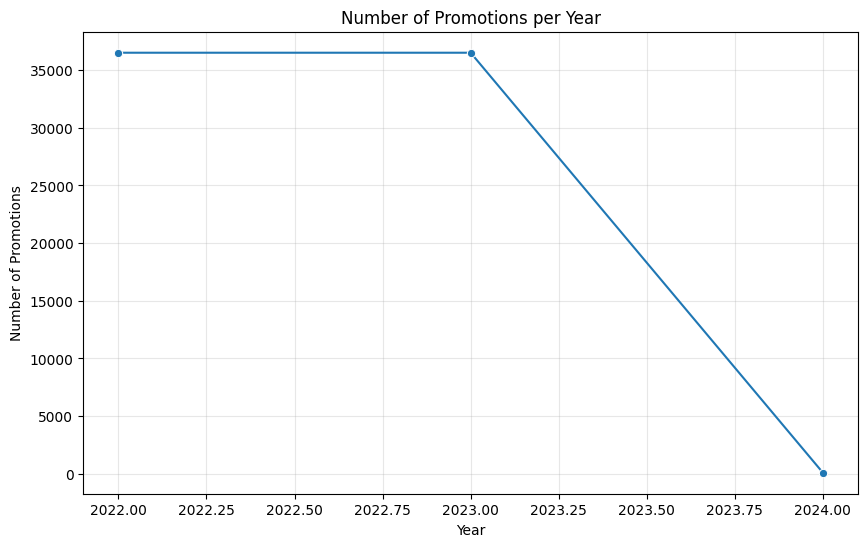

In [ ]:
import matplotlib.pyplot as plt

# Make sure you have the grouped data with count_promo
promo_by_year = (
    retail.groupby('Year')                    # replace 'df' with your actual dataframe name
    .agg(count_promo=('Holiday/Promotion', 'count'))   # adjust column name if needed
    .reset_index()
)

# Now plot using the correct dataframe
plt.figure(figsize=(10, 6))
sns.lineplot(data=promo_by_year, x='Year', y='count_promo', marker='o')

plt.title('Number of Promotions per Year')
plt.xlabel('Year')
plt.ylabel('Number of Promotions')
plt.grid(True, alpha=0.3)
plt.show()

We could see that the holidays/promotion has dropped so bad at 2024.

Lets check tthe oerall sales at 2024, it maybe the commonsense that low promo = low sales, butt we still need to see to avoid bias

In [ ]:
retail.head(3)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Year,Month,Month_Name
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,No,29.69,Autumn,2022,1,January
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,No,66.16,Autumn,2022,1,January
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,Yes,31.32,Summer,2022,1,January


In [ ]:
sales_2024_by_category = (
    retail[retail['Year'] == 2024]
    .groupby('Category')
    .agg(
        total_transactions=('Category', 'count'),
    )
    .round(2)
    .reset_index()
    .sort_values('total_transactions', ascending=False)
)
print("2024 sales per category")
print(sales_2024_by_category)

2024 sales per category
      Category  total_transactions
4         Toys                  25
1  Electronics                  24
2    Furniture                  19
3    Groceries                  18
0     Clothing                  14


Lets compare to 2022, the peak off discounts

In [ ]:
sales_2022_by_category = (
    retail[retail['Year'] == 2022]
    .groupby('Category')
    .agg(
        total_transactions=('Category', 'count'),
    )
    .round(2)
    .reset_index()
    .sort_values('total_transactions', ascending=False)
)
print("2022 sales per category")
print(sales_2022_by_category)

2022 sales per category
      Category  total_transactions
3    Groceries                7357
4         Toys                7304
0     Clothing                7294
2    Furniture                7290
1  Electronics                7255


we could see here that the sales arew heavily dependent on the promo. This is problematic, promos that drives sales explains that the original price does not convince target customers for the quality thats why some of them waits for promo just to make purchase.

Lets see if there are other variables that could affect like the season and the location

In [ ]:
loc_promo = (
    retail[retail['Year'] == 2022]
    .groupby('Region')
    .agg(
        count_promo = ('Holiday/Promotion', 'count')
    )
    .reset_index()
    .sort_values('count_promo', ascending=False)
    [['Region','count_promo']]
)
print("2022 promo per region")
print(loc_promo.head(5))

2022 promo per region
  Region  count_promo
0   East         9164
1  North         9122
3   West         9110
2  South         9104


In [ ]:
new_loc_promo = (
    retail[retail['Year'] == 2024]
    .groupby('Region')
    .agg(
        count_promo = ('Holiday/Promotion', 'count')
    )
    .reset_index()
    .sort_values('count_promo', ascending=False)
    [['Region','count_promo']]
)
print("2024 promo per region")
print(new_loc_promo.head(5))

2024 promo per region
  Region  count_promo
1  North           30
3   West           29
0   East           27
2  South           14


In [ ]:
weather_promo = (
    retail[retail['Year'] == 2022]
    .groupby('Weather Condition')
    .agg(
        count_promo = ('Holiday/Promotion', 'count')
    )
    .reset_index()
    .sort_values('count_promo', ascending=False)
)
print("2022 promo per weather")
print(weather_promo.head(5))


2022 promo per weather
  Weather Condition  count_promo
3             Sunny         9177
2             Snowy         9128
0            Cloudy         9116
1             Rainy         9079


In [ ]:
new_weather_promo = (
    retail[retail['Year'] == 2024]
    .groupby('Weather Condition')
    .agg(
        count_promo = ('Holiday/Promotion', 'count')
    )
    .reset_index()
    .sort_values('count_promo', ascending=False)
)
print("2024 promo per weather")
print(new_weather_promo.head(5))


2024 promo per weather
  Weather Condition  count_promo
2             Snowy           30
0            Cloudy           26
1             Rainy           23
3             Sunny           21


Now, we need to create the revenue data using the units sold and the price for the inferential analysis in predicting the sales for the year 2025 based on variables such as tthe promo, weather and region.

In [ ]:
# Create Total Revenue column
retail['Total_Revenue'] = retail['Units Sold'] * retail['Price']

# Check the result
print("Total Revenue column created successfully!")
print(retail[['Units Sold', 'Price', 'Total_Revenue']].head(10))

# Basic statistics of new column
print("\nTotal Revenue Statistics:")
print(retail['Total_Revenue'].describe())

Total Revenue column created successfully!
   Units Sold  Price  Total_Revenue
0         127  33.50        4254.50
1         150  63.01        9451.50
2          65  27.99        1819.35
3          61  32.72        1995.92
4          14  73.64        1030.96
5         128  76.83        9834.24
6          97  34.16        3313.52
7         312  97.99       30572.88
8         175  20.74        3629.50
9          28  59.99        1679.72

Total Revenue Statistics:
count    73100.000000
mean      7527.070929
std       7537.500441
min          0.000000
25%       2024.632500
50%       4956.090000
75%      10618.605000
max      47860.470000
Name: Total_Revenue, dtype: float64


In [ ]:
# Create Total Revenue and round to 2 decimal places
retail['Total_Revenue'] = (retail['Units Sold'] * retail['Price']).round(2)

print("✅ Total Revenue column created!")
print(retail[['Units Sold', 'Price', 'Total_Revenue']].head())

✅ Total Revenue column created!
   Units Sold  Price  Total_Revenue
0         127  33.50        4254.50
1         150  63.01        9451.50
2          65  27.99        1819.35
3          61  32.72        1995.92
4          14  73.64        1030.96


In [ ]:
category_revenue = (
    retail[retail['Year'] == 2022]
    .groupby('Category')
    .agg(
        total_revenue=('Total_Revenue', 'sum'),
        total_units=('Units Sold', 'sum'),
        avg_price=('Price', 'mean'),
        transaction_count=('Date', 'count')
    )
    .round(2)
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)

print("Revenue by 2022:")
print(category_revenue)

Revenue by 2022:
      Category  total_revenue  total_units  avg_price  transaction_count
3    Groceries    56563007.45      1011162      55.70               7357
2    Furniture    55499097.61      1002118      55.38               7290
4         Toys    55262599.57      1000826      54.96               7304
0     Clothing    54676496.68       995680      54.85               7294
1  Electronics    54036115.42       981838      55.53               7255


In [ ]:
new_category_revenue = (
    retail[retail['Year'] == 2024]
    .groupby('Category')
    .agg(
        total_revenue=('Total_Revenue', 'sum'),
        total_units=('Units Sold', 'sum'),
        avg_price=('Price', 'mean'),
        transaction_count=('Date', 'count')
    )
    .round(2)
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)

print("Revenue by 2024:")
print(new_category_revenue)

Revenue by 2024:
      Category  total_revenue  total_units  avg_price  transaction_count
2    Furniture      188555.05         3053      59.11                 19
1  Electronics      153246.41         3334      50.22                 24
4         Toys      150165.71         3240      49.29                 25
3    Groceries      115906.40         2227      57.12                 18
0     Clothing       80250.79         1390      52.77                 14


There's a lot of changes occur especially in essential once

INFERENTIAL ANALYSIS

Lets predict using Linear regression analysis see what would be their sales at year 2025

In [ ]:
yearly_revenue = (
    retail.groupby('Year')
    .agg(
        total_revenue=('Total_Revenue', 'sum'),
        total_units=('Units Sold', 'sum'),
)
    .round(2)
    .reset_index()
)

print("Yearly Revenue Data:")
print(yearly_revenue)

Yearly Revenue Data:
   Year  total_revenue  total_units
0  2022   2.760373e+08      4991624
1  2023   2.735034e+08      4970714
2  2024   6.881244e+05        13244


In [ ]:
yearly_revenue = pd.DataFrame({
    'Year': [2022, 2023, 2024],
    'Total_Revenue': [2.760373e+08, 2.735034e+08 , 881244e+05]
})

print("Yearly Revenue Data:")
print(yearly_revenue)


Yearly Revenue Data:
   Year  Total_Revenue
0  2022   2.760373e+08
1  2023   2.735034e+08
2  2024   8.812440e+10


In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np


X = yearly_revenue[['Year']]
y = yearly_revenue['Total_Revenue']


model = LinearRegression()
model.fit(X, y)


future_year = pd.DataFrame({'Year': [2025]})
prediction_2025 = model.predict(future_year)

print(f"\nPredicted Revenue for 2025: ${prediction_2025[0]:,.2f}")


Predicted Revenue for 2025: $117,406,342,933.33


Let's visualize

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


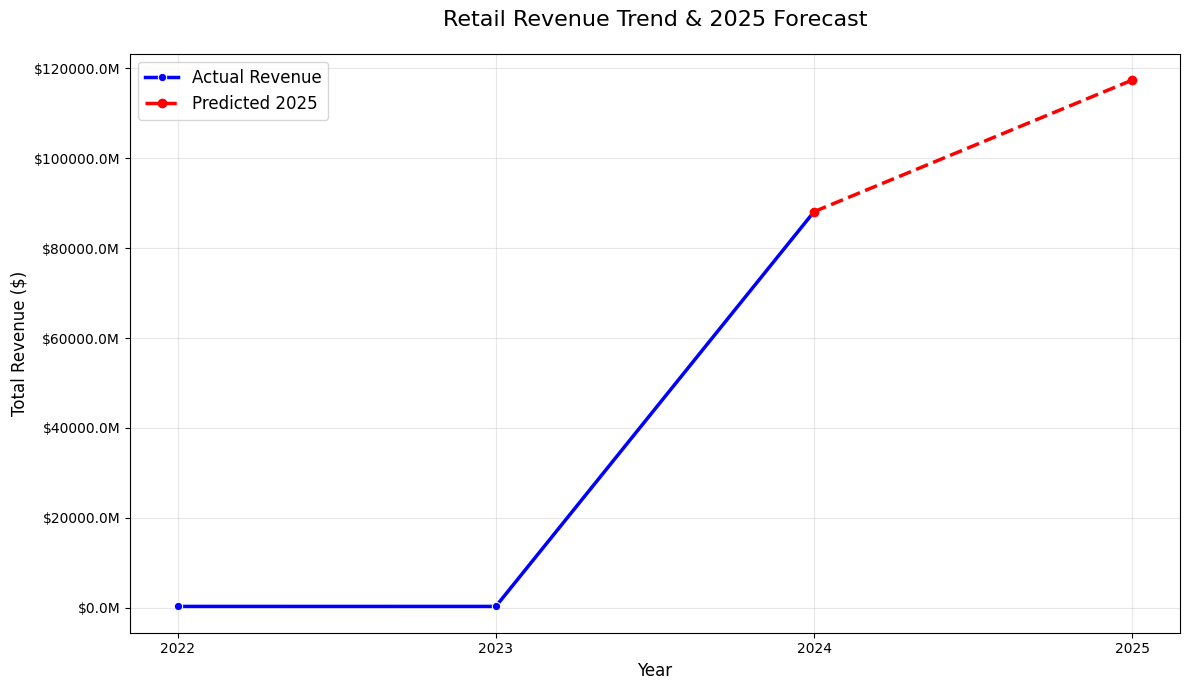

Predicted Revenue for 2025: $117,406,342,933.33


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


yearly_data = pd.DataFrame({
    'Year': [2022, 2023, 2024],
    'Total_Revenue': [ 2.760373e+08, 2.735034e+08, 881244e+05]}
)


X = yearly_data[['Year']]
y = yearly_data['Total_Revenue']

model = LinearRegression()
model.fit(X, y)

pred_2025 = model.predict([[2025]])[0]

future = pd.DataFrame({'Year': [2025], 'Total_Revenue': [pred_2025]})
full_data = pd.concat([yearly_data, future], ignore_index=True)


plt.figure(figsize=(12, 7))


sns.lineplot(data=yearly_data, x='Year', y='Total_Revenue',
             marker='o', linewidth=2.5, label='Actual Revenue', color='blue')


plt.plot(full_data['Year'].tail(2), full_data['Total_Revenue'].tail(2),
         marker='o', linestyle='--', color='red', linewidth=2.5, label='Predicted 2025')

plt.title('Retail Revenue Trend & 2025 Forecast', fontsize=16, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)


plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1_000_000:.1f}M'))

plt.xticks([2022, 2023, 2024, 2025])
plt.tight_layout()
plt.show()


print(f"Predicted Revenue for 2025: ${pred_2025:,.2f}")


something is off here, we know as we explore that 2024 has a bad sales but the whole revenue is out of reach. Let's inestigate whats going on

In [ ]:
print("Total Revenue Statistics:")
print(retail['Total_Revenue'].describe())

print("\nTotal Revenue by Year:")
print(retail.groupby('Year')['Total_Revenue'].sum())

Total Revenue Statistics:
count    73100.000000
mean      7527.070929
std       7537.500441
min          0.000000
25%       2024.632500
50%       4956.090000
75%      10618.605000
max      47860.470000
Name: Total_Revenue, dtype: float64

Total Revenue by Year:
Year
2022    2.760373e+08
2023    2.735034e+08
2024    6.881244e+05
Name: Total_Revenue, dtype: float64


Thats the problem, there is an outlier here. as you could see in .describe the range between the min and max is frankly way too far.

If thats the case, since we use mean as the way to deescribe the whole data in revenue, lets use median instead as this gets the middle part of the data which is applicable for data with big gaps like this one

In [ ]:
yearly_summary = (
    retail.groupby('Year')
    .agg(
        total_transactions=('Date', 'count'),
        total_revenue=('Total_Revenue', 'sum'),
        revenue_median=('Total_Revenue', 'median'),
        max_revenue=('Total_Revenue', 'max')
    )
    .round(2)
    .reset_index()
)

print("Yearly Revenue Summary:")
print(yearly_summary)

Yearly Revenue Summary:
   Year  total_transactions  total_revenue  revenue_median  max_revenue
0  2022               36500   2.760373e+08         4985.94     45584.12
1  2023               36500   2.735034e+08         4933.83     47860.47
2  2024                 100   6.881244e+05         4338.46     32186.26


Lets do the linear regression for the second time

Yearly Revenue Data:
   Year  Total_Revenue
0  2022        4985.94
1  2023        4933.83
2  2024        4338.46

Predicted Total Revenue for 2025: $4,105.26


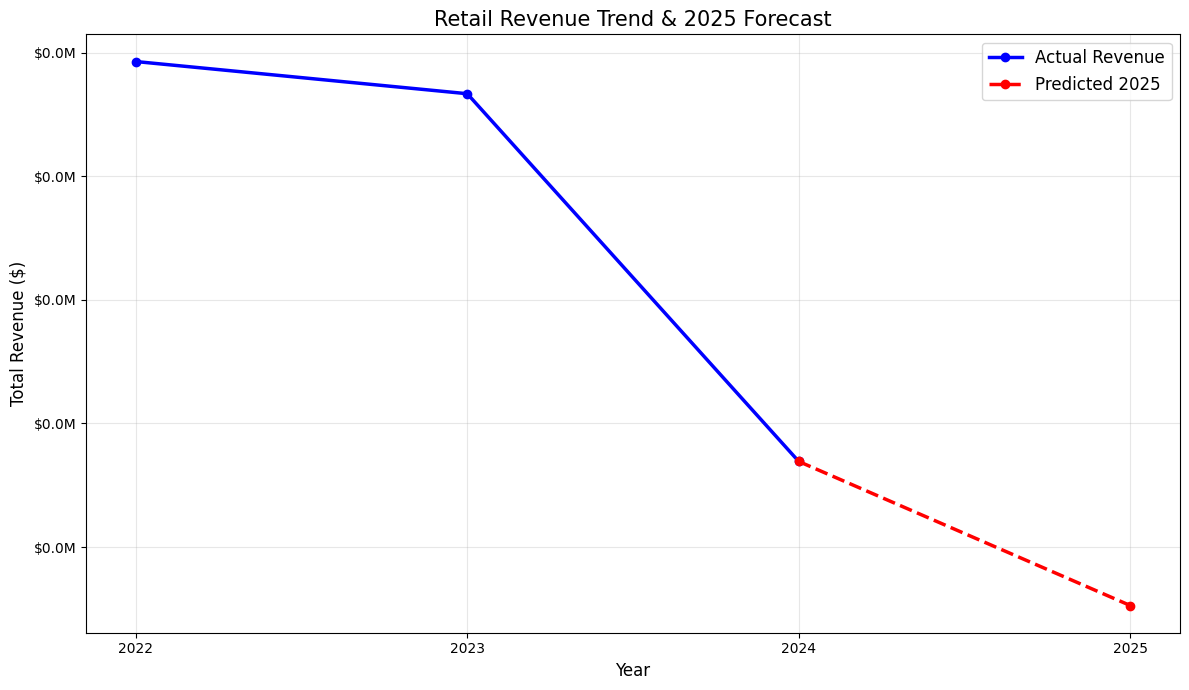

In [ ]:
yearly_revenue = pd.DataFrame({
    'Year': [2022, 2023, 2024],
    'Total_Revenue': [4985.94, 4933.83,  4338.46]   # using the median instead of the total revenue
})

print("Yearly Revenue Data:")
print(yearly_revenue)

# === Linear Regression ===
X = yearly_revenue[['Year']]
y = yearly_revenue['Total_Revenue']

model = LinearRegression()
model.fit(X, y)

# Predict 2025
future = pd.DataFrame({'Year': [2025]})
pred_2025 = model.predict(future)[0]

print(f"\nPredicted Total Revenue for 2025: ${pred_2025:,.2f}")

# === Visualization ===
plt.figure(figsize=(12, 7))

# Plot actual data
plt.plot(yearly_revenue['Year'], yearly_revenue['Total_Revenue'],
         marker='o', linewidth=2.5, label='Actual Revenue', color='blue')

# Plot prediction line
plt.plot([2024, 2025], [yearly_revenue['Total_Revenue'].iloc[-1], pred_2025],
         marker='o', linestyle='--', color='red', linewidth=2.5, label='Predicted 2025')

plt.title('Retail Revenue Trend & 2025 Forecast', fontsize=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

# Format y-axis to show in millions
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1_000_000:.1f}M'))

plt.xticks([2022, 2023, 2024, 2025])
plt.tight_layout()
plt.show()

This is better unlike the first one makes sense

In cocnlusion:
The analysis reveals that the company’s sales are heavily dependent on promotions. The high sales volume in 2022 was largely artificial — driven by aggressive discounting rather than genuine customer demand. When promotional activities were significantly reduced in 2024, total transactions collapsed dramatically (from ~36,500 to just 100), confirming a dangerous reliance on price cuts.


A clear shift in customer behavior was also observed: during the low-promo period in 2024, customers moved away from essential items (such as Groceries and Clothing) and toward non-essential categories (Toys and Furniture). This suggests that heavy discounting may have trained customers to only buy during promotions.



Key Recommendations:

Reduce heavy dependence on promotions
The company should move away from blanket discounting and focus on building organic demand through product quality, brand positioning, and customer loyalty programs.
Adopt smarter, targeted promotions
Use data on region and weather conditions to plan more effective and timely promotions instead of broad, high-volume campaigns.
Focus on demand forecasting
Future analysis should include predictive modeling by region and weather to anticipate demand, optimize inventory, and avoid overstocking low-demand products.
Collaborate with the Marketing Department
Work closely with marketing to strengthen B2C strategies, improve brand perception, and reduce the need for constant discounting.